# Week 7: Semantic Stock Search - Complete Notebook

This notebook contains all tasks for Week 7:
1. Task 2: Manual Similarity Calculation with PCA Visualization
2. Task 3 & 4: Semantic Search with Evaluation Framework
3. Advanced Task 2: Model Comparison (MiniLM vs MPNet)

## Task 2: Manual Similarity Calculation

Products: "Lego Castle", "Wooden Blocks", "Action Figure"

Steps:
1. Generate embeddings using sentence-transformers
2. Manually calculate cosine similarity using numpy
3. Plot in 2D using PCA
4. Analyze why Lego is closer to Wooden Blocks

In [1]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

model = SentenceTransformer('all-MiniLM-L6-v2')

products = [
    {"name": "Lego Castle", "description": "A medieval castle building set with knights and horses"},
    {"name": "Wooden Blocks", "description": "Classic wooden building blocks for creative construction"},
    {"name": "Action Figure", "description": "Superhero action figure with movable joints and accessories"}
]

print("=" * 60)
print("TASK 2: MANUAL SIMILARITY CALCULATION")
print("=" * 60)

texts = [f"{p['name']} {p['description']}" for p in products]
print("\nProduct Texts:")
for i, text in enumerate(texts):
    print(f"  {i+1}. {text}")

print("\n" + "-" * 60)
print("Step 2a: Generating Embeddings (384 dimensions)")
print("-" * 60)

embeddings = []
for i, text in enumerate(texts):
    embedding = model.encode(text, convert_to_numpy=True)
    embeddings.append(embedding)
    print(f"\nProduct {i+1}: {products[i]['name']}")
    print(f"  Embedding shape: {embedding.shape}")
    print(f"  First 10 values: {embedding[:10]}")
    print(f"  Embedding norm: {np.linalg.norm(embedding):.4f}")

c:\Users\Arjun\anaconda3\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
W0315 15:03:07.110000 6212 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
c:\Users\Arjun\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


TASK 2: MANUAL SIMILARITY CALCULATION

Product Texts:
  1. Lego Castle A medieval castle building set with knights and horses
  2. Wooden Blocks Classic wooden building blocks for creative construction
  3. Action Figure Superhero action figure with movable joints and accessories

------------------------------------------------------------
Step 2a: Generating Embeddings (384 dimensions)
------------------------------------------------------------

Product 1: Lego Castle
  Embedding shape: (384,)
  First 10 values: [ 0.00061434  0.09518919 -0.0399071  -0.01570654 -0.03887387  0.00051745
 -0.08158735 -0.00089198 -0.03973554 -0.02651392]
  Embedding norm: 1.0000

Product 2: Wooden Blocks
  Embedding shape: (384,)
  First 10 values: [-0.0271995   0.02490544  0.01758764 -0.03169104  0.01908424 -0.01995768
 -0.02843846  0.00553759 -0.00813842  0.03524958]
  Embedding norm: 1.0000

Product 3: Action Figure
  Embedding shape: (384,)
  First 10 values: [-0.06580563 -0.02089073 -0.06022774 -0.0

In [2]:
print("\n" + "-" * 60)
print("Step 2b: MANUAL Cosine Similarity Calculation")
print("-" * 60)

def manual_cosine_similarity(v1: np.ndarray, v2: np.ndarray) -> float:
    dot_product = np.dot(v1, v2)
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    
    print(f"  Dot product: {dot_product:.6f}")
    print(f"  Norm1: {norm1:.6f}")
    print(f"  Norm2: {norm2:.6f}")
    
    if norm1 == 0 or norm2 == 0:
        return 0.0
    
    similarity = dot_product / (norm1 * norm2)
    return similarity

pairs = [
    (0, 1, "Lego Castle", "Wooden Blocks"),
    (0, 2, "Lego Castle", "Action Figure"),
    (1, 2, "Wooden Blocks", "Action Figure")
]

similarities = {}
print("\nCosine Similarities:")
for i, j, name1, name2 in pairs:
    print(f"\n{name1} vs {name2}:")
    sim = manual_cosine_similarity(embeddings[i], embeddings[j])
    similarities[(i, j)] = sim
    print(f"  Cosine Similarity: {sim:.6f} ({sim*100:.2f}%)")


------------------------------------------------------------
Step 2b: MANUAL Cosine Similarity Calculation
------------------------------------------------------------

Cosine Similarities:

Lego Castle vs Wooden Blocks:
  Dot product: 0.364111
  Norm1: 1.000000
  Norm2: 1.000000
  Cosine Similarity: 0.364111 (36.41%)

Lego Castle vs Action Figure:
  Dot product: 0.196210
  Norm1: 1.000000
  Norm2: 1.000000
  Cosine Similarity: 0.196210 (19.62%)

Wooden Blocks vs Action Figure:
  Dot product: 0.112504
  Norm1: 1.000000
  Norm2: 1.000000
  Cosine Similarity: 0.112504 (11.25%)



------------------------------------------------------------
Step 2c: PCA Visualization (384D → 2D)
------------------------------------------------------------

Explained variance ratio: [0.5953633  0.40463668]
Total variance preserved: 100.00%

2D Coordinates:
  Lego Castle: (-0.2744, -0.6061)
  Wooden Blocks: (-0.4995, 0.4990)
  Action Figure: (0.7739, 0.1071)


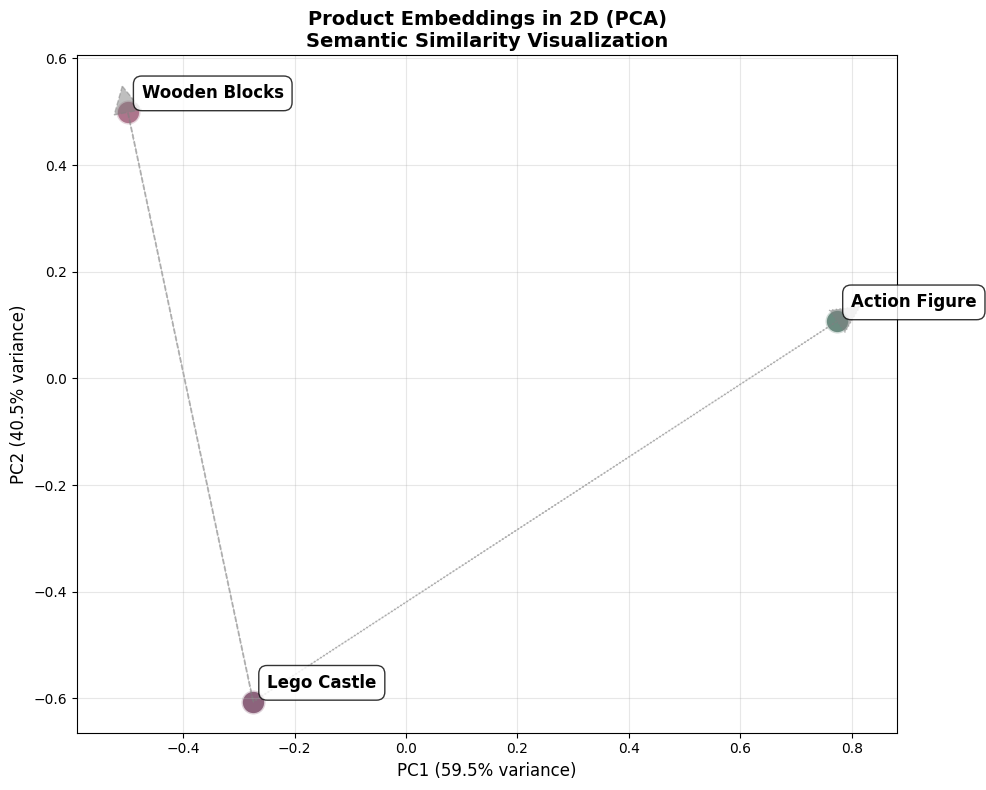

Plot displayed above


In [3]:
print("\n" + "-" * 60)
print("Step 2c: PCA Visualization (384D → 2D)")
print("-" * 60)

embeddings_matrix = np.array(embeddings)
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_matrix)

print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance preserved: {sum(pca.explained_variance_ratio_)*100:.2f}%")

print("\n2D Coordinates:")
for i, product in enumerate(products):
    print(f"  {product['name']}: ({embeddings_2d[i, 0]:.4f}, {embeddings_2d[i, 1]:.4f})")

plt.figure(figsize=(10, 8))
colors = ['#5c2145', '#8b3a5c', '#2d5a4a']
for i, product in enumerate(products):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], 
                c=colors[i], s=300, alpha=0.7, edgecolors='white', linewidth=2)
    plt.annotate(product['name'], 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=12, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

lego_wooden_dist = np.linalg.norm(embeddings_2d[0] - embeddings_2d[1])
lego_action_dist = np.linalg.norm(embeddings_2d[0] - embeddings_2d[2])

plt.arrow(embeddings_2d[0, 0], embeddings_2d[0, 1],
          embeddings_2d[1, 0] - embeddings_2d[0, 0],
          embeddings_2d[1, 1] - embeddings_2d[0, 1],
          head_width=0.05, head_length=0.05, fc='gray', ec='gray', alpha=0.5, linestyle='--')
plt.arrow(embeddings_2d[0, 0], embeddings_2d[0, 1],
          embeddings_2d[2, 0] - embeddings_2d[0, 0],
          embeddings_2d[2, 1] - embeddings_2d[0, 1],
          head_width=0.05, head_length=0.05, fc='gray', ec='gray', alpha=0.5, linestyle=':')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('Product Embeddings in 2D (PCA)\nSemantic Similarity Visualization', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Plot displayed above")

In [5]:
print("\n" + "=" * 60)
print("Step 2d: ANALYSIS - Why is Lego closer to Wooden Blocks?")
print("=" * 60)

lego_wooden_sim = similarities[(0, 1)]
lego_action_sim = similarities[(0, 2)]

print(f"\nSimilarity Scores:")
print(f"  Lego Castle ↔ Wooden Blocks: {lego_wooden_sim:.4f} ({lego_wooden_sim*100:.2f}%)")
print(f"  Lego Castle ↔ Action Figure: {lego_action_sim:.4f} ({lego_action_sim*100:.2f}%)")
print(f"\nDifference: {abs(lego_wooden_sim - lego_action_sim)*100:.2f} percentage points")


Step 2d: ANALYSIS - Why is Lego closer to Wooden Blocks?

Similarity Scores:
  Lego Castle ↔ Wooden Blocks: 0.3641 (36.41%)
  Lego Castle ↔ Action Figure: 0.1962 (19.62%)

Difference: 16.79 percentage points


---

## Task 3 & 4: Semantic Search with Evaluation Framework

In [6]:
from typing import List, Dict, Any, Tuple

SEARCH_TEST_CASES = [
    {
        "query": "construction toys",
        "relevant_products": ["lego_castle_001", "lego_city_002", "wooden_blocks_003"],
        "irrelevant_products": ["teddy_bear_010", "action_figure_015", "doll_house_020"]
    },
    {
        "query": "gifts for toddlers",
        "relevant_products": ["soft_blocks_004", "plush_toy_005", "baby_rattle_006"],
        "irrelevant_products": ["puzzle_1000pc_020", "teen_board_game_025", "lego_technic_030"]
    },
    {
        "query": "educational toys",
        "relevant_products": ["math_learning_kit_001", "science_set_002", "alphabet_blocks_003"],
        "irrelevant_products": ["water_gun_010", "fidget_spinner_015", "stuffed_animal_020"]
    },
    {
        "query": "outdoor play",
        "relevant_products": ["swing_set_001", "sandbox_002", "water_slide_003"],
        "irrelevant_products": ["board_game_010", "lego_set_015", "puzzle_020"]
    },
    {
        "query": "creative building",
        "relevant_products": ["lego_classic_001", "wooden_blocks_002", "magnetic_tiles_003"],
        "irrelevant_products": ["action_figure_010", "rc_car_015", "doll_020"]
    }
]

In [7]:
class SemanticSearchService:
    def __init__(self, model_name: str = 'all-MiniLM-L6-v2'):
        self.model = SentenceTransformer(model_name)
        self.products = []
        self.embeddings = {}
        self.model_name = model_name
    
    def generate_product_text(self, product: Dict[str, Any]) -> str:
        return f"{product.get('name', '')} {product.get('description', '')} {product.get('category', '')} {product.get('brand', '')}"
    
    def compute_cosine_similarity(self, v1: np.ndarray, v2: np.ndarray) -> float:
        dot_product = np.dot(v1, v2)
        norm1 = np.linalg.norm(v1)
        norm2 = np.linalg.norm(v2)
        if norm1 == 0 or norm2 == 0:
            return 0.0
        return dot_product / (norm1 * norm2)
    
    def index_products(self, products: List[Dict[str, Any]]):
        self.products = products
        texts = [self.generate_product_text(p) for p in products]
        self.embeddings = self.model.encode(texts, convert_to_numpy=True)
    
    def search(self, query: str, top_k: int = 10) -> List[Tuple[Dict[str, Any], float]]:
        if len(self.products) == 0:
            return []
        
        query_embedding = self.model.encode(query, convert_to_numpy=True)
        
        results = []
        for i, product in enumerate(self.products):
            similarity = self.compute_cosine_similarity(query_embedding, self.embeddings[i])
            results.append((product, similarity))
        
        results.sort(key=lambda x: x[1], reverse=True)
        return results[:top_k]
    
    def evaluate_search(self, test_cases: List[Dict] = None) -> Dict[str, Any]:
        if test_cases is None:
            test_cases = SEARCH_TEST_CASES
        
        results = {
            "test_cases": [],
            "overall_precision": 0.0,
            "overall_recall": 0.0,
            "overall_f1": 0.0,
            "average_top_k_accuracy": 0.0
        }
        
        total_precision = 0.0
        total_recall = 0.0
        total_top_k_acc = 0.0
        
        for test_case in test_cases:
            query = test_case["query"]
            relevant = set(test_case["relevant_products"])
            irrelevant = set(test_case["irrelevant_products"])
            
            search_results = self.search(query, top_k=10)
            returned_ids = [r[0].get('id', '') for r in search_results]
            
            true_positives = len(set(returned_ids) & relevant)
            false_positives = len(set(returned_ids) & irrelevant)
            false_negatives = len(relevant - set(returned_ids))
            
            precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0.0
            recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0.0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            
            top_k_acc = 0.0
            for i, (product, score) in enumerate(search_results[:5]):
                if product.get('id', '') in relevant:
                    top_k_acc += 1
            top_k_acc /= 5
            
            total_precision += precision
            total_recall += recall
            total_top_k_acc += top_k_acc
            
            results["test_cases"].append({
                "query": query,
                "precision": precision,
                "recall": recall,
                "f1_score": f1,
                "top_5_accuracy": top_k_acc,
                "results_count": len(search_results)
            })
        
        num_cases = len(test_cases)
        results["overall_precision"] = total_precision / num_cases
        results["overall_recall"] = total_recall / num_cases
        results["overall_f1"] = 2 * (results["overall_precision"] * results["overall_recall"]) / (results["overall_precision"] + results["overall_recall"]) if (results["overall_precision"] + results["overall_recall"]) > 0 else 0.0
        results["average_top_k_accuracy"] = total_top_k_acc / num_cases
        
        return results

In [8]:
sample_products = [
    {"id": "lego_castle_001", "name": "Lego Castle", "description": "A medieval castle building set with knights and horses", "category": "Building Toys", "brand": "Lego"},
    {"id": "lego_city_002", "name": "Lego City", "description": "City building blocks with vehicles and minifigures", "category": "Building Toys", "brand": "Lego"},
    {"id": "wooden_blocks_003", "name": "Wooden Blocks", "description": "Classic wooden building blocks for creative construction", "category": "Building Toys", "brand": "Melissa & Doug"},
    {"id": "soft_blocks_004", "name": "Soft Blocks", "description": "Soft foam blocks safe for toddlers", "category": "Baby Toys", "brand": "Fisher-Price"},
    {"id": "plush_toy_005", "name": "Plush Teddy Bear", "description": "Soft cuddly teddy bear for toddlers", "category": "Plush Toys", "brand": "Gund"},
    {"id": "baby_rattle_006", "name": "Baby Rattle", "description": "Colorful rattle for infants", "category": "Baby Toys", "brand": "Fisher-Price"},
    {"id": "teddy_bear_010", "name": "Giant Teddy Bear", "description": "Large stuffed teddy bear for hugging", "category": "Plush Toys", "brand": "Gund"},
    {"id": "action_figure_015", "name": "Superhero Action Figure", "description": "Poseable superhero figure with accessories", "category": "Action Figures", "brand": "Marvel"},
    {"id": "doll_house_020", "name": "Doll House", "description": "Victorian style doll house with furniture", "category": "Dolls", "brand": "Barbie"},
    {"id": "math_learning_kit_001", "name": "Math Learning Kit", "description": "Educational math toys for kids learning numbers", "category": "Educational", "brand": "Learning Resources"},
    {"id": "science_set_002", "name": "Science Experiment Set", "description": "Chemistry set for young scientists", "category": "Educational", "brand": "Thames & Kosmos"},
    {"id": "alphabet_blocks_003", "name": "Alphabet Blocks", "description": "Wooden blocks with letters for learning", "category": "Educational", "brand": "Melissa & Doug"},
    {"id": "water_gun_010", "name": "Super Soaker", "description": "High pressure water gun for summer fun", "category": "Outdoor", "brand": "Nerf"},
    {"id": "fidget_spinner_015", "name": "Fidget Spinner", "description": "Stress relief toy for focus", "category": "Fidgets", "brand": "Spin Master"},
    {"id": "stuffed_animal_020", "name": "Stuffed Elephant", "description": "Cute plush elephant", "category": "Plush Toys", "brand": "Wild Republic"}
]

service = SemanticSearchService()
service.index_products(sample_products)

print("=" * 60)
print("TASK 3: SEMANTIC SEARCH")
print("=" * 60)

queries = [
    "construction toys",
    "building blocks for kids",
    "educational learning toys",
    "soft toys for babies"
]

for query in queries:
    print(f"\nQuery: '{query}'")
    print("-" * 40)
    results = service.search(query, top_k=5)
    for i, (product, score) in enumerate(results):
        print(f"  {i+1}. {product['name']} (score: {score:.4f})")
        print(f"     {product['description'][:60]}...")

c:\Users\Arjun\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


TASK 3: SEMANTIC SEARCH

Query: 'construction toys'
----------------------------------------
  1. Wooden Blocks (score: 0.6006)
     Classic wooden building blocks for creative construction...
  2. Lego City (score: 0.5638)
     City building blocks with vehicles and minifigures...
  3. Lego Castle (score: 0.5149)
     A medieval castle building set with knights and horses...
  4. Plush Teddy Bear (score: 0.4945)
     Soft cuddly teddy bear for toddlers...
  5. Stuffed Elephant (score: 0.4807)
     Cute plush elephant...

Query: 'building blocks for kids'
----------------------------------------
  1. Wooden Blocks (score: 0.6331)
     Classic wooden building blocks for creative construction...
  2. Alphabet Blocks (score: 0.5739)
     Wooden blocks with letters for learning...
  3. Soft Blocks (score: 0.5112)
     Soft foam blocks safe for toddlers...
  4. Lego City (score: 0.4958)
     City building blocks with vehicles and minifigures...
  5. Math Learning Kit (score: 0.3740)
     Ed

In [9]:
print("\n" + "=" * 60)
print("TASK 4: EVALUATION FRAMEWORK")
print("=" * 60)

eval_results = service.evaluate_search(SEARCH_TEST_CASES)

print("\nTest Case Results:")
print("-" * 60)
for case in eval_results["test_cases"]:
    print(f"\nQuery: '{case['query']}'")
    print(f"  Precision: {case['precision']:.2f}")
    print(f"  Recall: {case['recall']:.2f}")
    print(f"  F1 Score: {case['f1_score']:.2f}")
    print(f"  Top-5 Accuracy: {case['top_5_accuracy']:.2f}")

print("\n" + "-" * 60)
print("OVERALL METRICS:")
print(f"  Average Precision: {eval_results['overall_precision']:.3f}")
print(f"  Average Recall: {eval_results['overall_recall']:.3f}")
print(f"  Average F1 Score: {eval_results['overall_f1']:.3f}")
print(f"  Top-K Accuracy: {eval_results['average_top_k_accuracy']:.3f}")

print("\n" + "=" * 60)


TASK 4: EVALUATION FRAMEWORK

Test Case Results:
------------------------------------------------------------

Query: 'construction toys'
  Precision: 0.60
  Recall: 1.00
  F1 Score: 0.75
  Top-5 Accuracy: 0.60

Query: 'gifts for toddlers'
  Precision: 1.00
  Recall: 1.00
  F1 Score: 1.00
  Top-5 Accuracy: 0.60

Query: 'educational toys'
  Precision: 0.67
  Recall: 0.67
  F1 Score: 0.67
  Top-5 Accuracy: 0.20

Query: 'outdoor play'
  Precision: 0.00
  Recall: 0.00
  F1 Score: 0.00
  Top-5 Accuracy: 0.00

Query: 'creative building'
  Precision: 0.00
  Recall: 0.00
  F1 Score: 0.00
  Top-5 Accuracy: 0.00

------------------------------------------------------------
OVERALL METRICS:
  Average Precision: 0.453
  Average Recall: 0.533
  Average F1 Score: 0.490
  Top-K Accuracy: 0.280



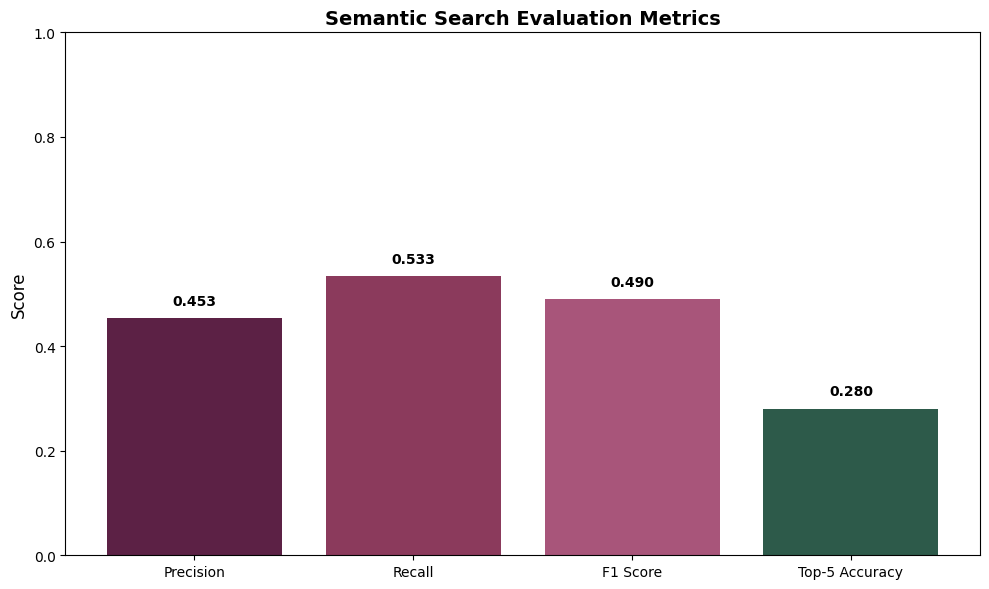

In [10]:
metrics = ['Precision', 'Recall', 'F1 Score', 'Top-5 Accuracy']
values = [
    eval_results['overall_precision'],
    eval_results['overall_recall'],
    eval_results['overall_f1'],
    eval_results['average_top_k_accuracy']
]

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['#5c2145', '#8b3a5c', '#a8557a', '#2d5a4a'])
plt.ylim(0, 1)
plt.ylabel('Score', fontsize=12)
plt.title('Semantic Search Evaluation Metrics', fontsize=14, fontweight='bold')

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

---

## Advanced Task 2: Model Comparison

In [11]:
import time

model_products = [
    {"id": "lego_castle_001", "name": "Lego Castle", "description": "A medieval castle building set with knights and horses", "category": "Building Toys", "brand": "Lego"},
    {"id": "lego_city_002", "name": "Lego City", "description": "City building blocks with vehicles and minifigures", "category": "Building Toys", "brand": "Lego"},
    {"id": "wooden_blocks_003", "name": "Wooden Blocks", "description": "Classic wooden building blocks for creative construction", "category": "Building Toys", "brand": "Melissa & Doug"},
    {"id": "soft_blocks_004", "name": "Soft Blocks", "description": "Soft foam blocks safe for toddlers", "category": "Baby Toys", "brand": "Fisher-Price"},
    {"id": "plush_toy_005", "name": "Plush Teddy Bear", "description": "Soft cuddly teddy bear for toddlers", "category": "Plush Toys", "brand": "Gund"},
    {"id": "baby_rattle_006", "name": "Baby Rattle", "description": "Colorful rattle for infants", "category": "Baby Toys", "brand": "Fisher-Price"},
    {"id": "teddy_bear_010", "name": "Giant Teddy Bear", "description": "Large stuffed teddy bear for hugging", "category": "Plush Toys", "brand": "Gund"},
    {"id": "action_figure_015", "name": "Superhero Action Figure", "description": "Poseable superhero figure with accessories", "category": "Action Figures", "brand": "Marvel"},
    {"id": "doll_house_020", "name": "Doll House", "description": "Victorian style doll house with furniture", "category": "Dolls", "brand": "Barbie"},
    {"id": "math_learning_kit_001", "name": "Math Learning Kit", "description": "Educational math toys for kids learning numbers", "category": "Educational", "brand": "Learning Resources"},
    {"id": "science_set_002", "name": "Science Experiment Set", "description": "Chemistry set for young scientists", "category": "Educational", "brand": "Thames & Kosmos"},
    {"id": "alphabet_blocks_003", "name": "Alphabet Blocks", "description": "Wooden blocks with letters for learning", "category": "Educational", "brand": "Melissa & Doug"},
    {"id": "water_gun_010", "name": "Super Soaker", "description": "High pressure water gun for summer fun", "category": "Outdoor", "brand": "Nerf"},
    {"id": "fidget_spinner_015", "name": "Fidget Spinner", "description": "Stress relief toy for focus", "category": "Fidgets", "brand": "Spin Master"},
    {"id": "stuffed_animal_020", "name": "Stuffed Elephant", "description": "Cute plush elephant", "category": "Plush Toys", "brand": "Wild Republic"},
    {"id": "trampoline_001", "name": "Kids Trampoline", "description": "Small indoor trampoline for active play", "category": "Outdoor", "brand": "Little Tikes"},
    {"id": "play_kitchen_002", "name": "Play Kitchen", "description": "Toy kitchen set with utensils and sounds", "category": "Pretend Play", "brand": "Step2"},
    {"id": "doctor_kit_003", "name": "Doctor Kit", "description": "Toy medical kit for pretend doctor play", "category": "Pretend Play", "brand": "Fisher-Price"},
    {"id": "rc_car_004", "name": "RC Race Car", "description": "Remote controlled racing car", "category": "Vehicles", "brand": "Hot Wheels"},
    {"id": "train_set_005", "name": "Wooden Train Set", "description": "Classic wooden train track with engines", "category": "Vehicles", "brand": "Brio"}
]

test_query = "toys for 5-year-olds"

class ModelComparator:
    def __init__(self, model_name: str):
        print(f"\nLoading {model_name}...")
        start_time = time.time()
        self.model = SentenceTransformer(model_name)
        self.load_time = time.time() - start_time
        self.model_name = model_name
        self.dimension = self.model.get_sentence_embedding_dimension()
        print(f"  Loaded in {self.load_time:.2f}s")
        print(f"  Embedding dimension: {self.dimension}")
    
    def index_products(self, products):
        self.products = products
        texts = [f"{p['name']} {p['description']} {p['category']} {p['brand']}" for p in products]
        
        start_time = time.time()
        self.embeddings = self.model.encode(texts, convert_to_numpy=True)
        self.index_time = time.time() - start_time
        
        print(f"  Indexed {len(products)} products in {self.index_time:.3f}s")
    
    def search(self, query: str, top_k: int = 5):
        start_time = time.time()
        query_embedding = self.model.encode(query, convert_to_numpy=True)
        encode_time = time.time() - start_time
        
        results = []
        for i, product in enumerate(self.products):
            sim = np.dot(query_embedding, self.embeddings[i]) / (np.linalg.norm(query_embedding) * np.linalg.norm(self.embeddings[i]))
            results.append((product, sim))
        
        results.sort(key=lambda x: x[1], reverse=True)
        return results[:top_k], encode_time

print("=" * 70)
print("ADVANCED TASK 2: COMPARING EMBEDDING MODELS")
print("=" * 70)

ADVANCED TASK 2: COMPARING EMBEDDING MODELS


In [12]:
print("\n" + "-" * 70)
print("Model A: all-MiniLM-L6-v2 (384 dimensions, fast)")
print("-" * 70)
model_a = ModelComparator('all-MiniLM-L6-v2')
model_a.index_products(model_products)
results_a, encode_time_a = model_a.search(test_query, top_k=5)

print("\nTop 5 results for query: 'toys for 5-year-olds'")
for i, (product, score) in enumerate(results_a):
    print(f"  {i+1}. {product['name']} ({product['category']}) - Score: {score:.4f}")
print(f"  Query encoding time: {encode_time_a*1000:.2f}ms")


----------------------------------------------------------------------
Model A: all-MiniLM-L6-v2 (384 dimensions, fast)
----------------------------------------------------------------------

Loading all-MiniLM-L6-v2...
  Loaded in 3.31s
  Embedding dimension: 384
  Indexed 20 products in 0.270s

Top 5 results for query: 'toys for 5-year-olds'
  1. Math Learning Kit (Educational) - Score: 0.5262
  2. Plush Teddy Bear (Plush Toys) - Score: 0.5238
  3. Baby Rattle (Baby Toys) - Score: 0.4925
  4. Kids Trampoline (Outdoor) - Score: 0.4849
  5. Wooden Blocks (Building Toys) - Score: 0.4691
  Query encoding time: 63.69ms


In [13]:
print("\n" + "-" * 70)
print("Model B: all-mpnet-base-v2 (768 dimensions, slower)")
print("-" * 70)
model_b = ModelComparator('all-mpnet-base-v2')
model_b.index_products(model_products)
results_b, encode_time_b = model_b.search(test_query, top_k=5)

print("\nTop 5 results for query: 'toys for 5-year-olds'")
for i, (product, score) in enumerate(results_b):
    print(f"  {i+1}. {product['name']} ({product['category']}) - Score: {score:.4f}")
print(f"  Query encoding time: {encode_time_b*1000:.2f}ms")


----------------------------------------------------------------------
Model B: all-mpnet-base-v2 (768 dimensions, slower)
----------------------------------------------------------------------

Loading all-mpnet-base-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\Arjun\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:157: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Arjun\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Loaded in 70.20s
  Embedding dimension: 768
  Indexed 20 products in 0.880s

Top 5 results for query: 'toys for 5-year-olds'
  1. Plush Teddy Bear (Plush Toys) - Score: 0.6023
  2. Wooden Blocks (Building Toys) - Score: 0.4899
  3. Giant Teddy Bear (Plush Toys) - Score: 0.4865
  4. Soft Blocks (Baby Toys) - Score: 0.4706
  5. Math Learning Kit (Educational) - Score: 0.4644
  Query encoding time: 66.53ms



COMPARISON SUMMARY

Metric                         MiniLM (384D)        MPNet (768D)        
----------------------------------------------------------------------
Model Size                     ~80 MB               ~420 MB             
Embedding Dimensions           384                  768                 
Load Time                      3.31s                70.20s              
Indexing Time                  270.3ms              880.3ms             
Query Encode Time              63.69ms              66.53ms             


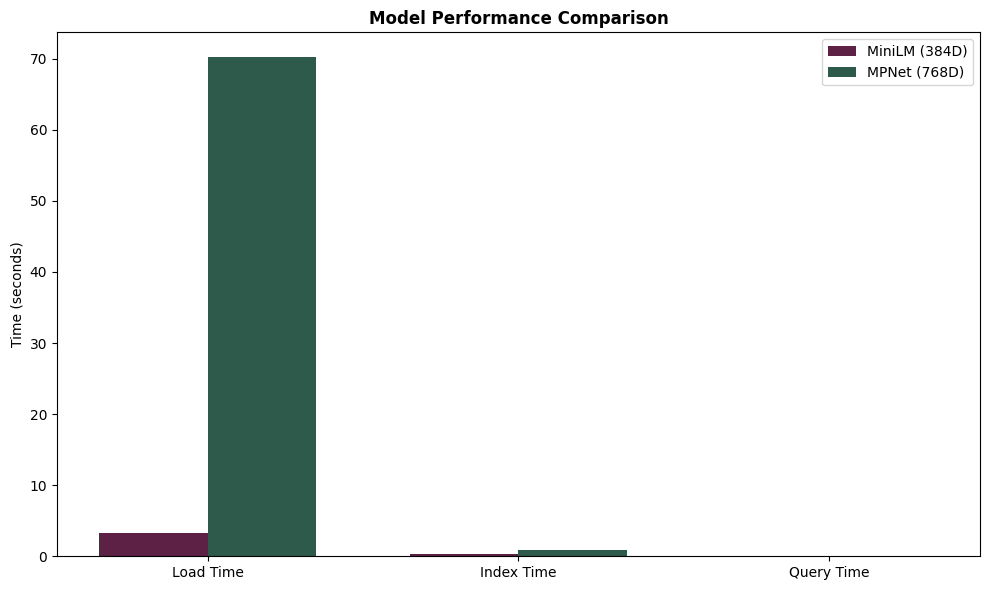

In [14]:
print("\n" + "=" * 70)
print("COMPARISON SUMMARY")
print("=" * 70)

print(f"\n{'Metric':<30} {'MiniLM (384D)':<20} {'MPNet (768D)':<20}")
print("-" * 70)
print(f"{'Model Size':<30} {'~80 MB':<20} {'~420 MB':<20}")
print(f"{'Embedding Dimensions':<30} {model_a.dimension:<20} {model_b.dimension:<20}")
print(f"{'Load Time':<30} {f'{model_a.load_time:.2f}s':<20} {f'{model_b.load_time:.2f}s':<20}")
print(f"{'Indexing Time':<30} {f'{model_a.index_time*1000:.1f}ms':<20} {f'{model_b.index_time*1000:.1f}ms':<20}")
print(f"{'Query Encode Time':<30} {f'{encode_time_a*1000:.2f}ms':<20} {f'{encode_time_b*1000:.2f}ms':<20}")

metrics = ['Load Time', 'Index Time', 'Query Time']
minilm_times = [model_a.load_time, model_a.index_time, encode_time_a]
mpnet_times = [model_b.load_time, model_b.index_time, encode_time_b]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, minilm_times, width, label='MiniLM (384D)', color='#5c2145')
bars2 = ax.bar(x + width/2, mpnet_times, width, label='MPNet (768D)', color='#2d5a4a')

ax.set_ylabel('Time (seconds)')
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.tight_layout()
plt.show()